# **Titanic Survival Prediction**

## Project Overview

This project explores the factors associated with passenger survival during the Titanic disaster and develops machine learning models to predict whether a passenger survived.

The project follows an end-to-end data science workflow, including data understanding, data cleaning, exploratory data analysis, feature engineering, data preprocessing, model development, and model evaluation.

## Objectives

- Explore and understand the Titanic dataset.
- Identify patterns and factors associated with passenger survival.
- Handle missing values and prepare the data for machine learning.
- Engineer relevant features to improve predictive performance.
- Develop and compare multiple classification models.
- Evaluate model performance using appropriate metrics.

# 1. Setup and Imports

In [193]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model selection
from sklearn.model_selection import cross_val_score, train_test_split

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Dataset access
import kagglehub

# Reproducibility
np.random.seed(42)

# 2. Data Loading

The project uses separate training and test datasets. The training dataset contains the target variable, `Survived`, while the test dataset is used for generating predictions.

In [102]:
# Load training and test datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Training dataset loaded successfully.")
print("Test dataset loaded successfully.")

Training dataset loaded successfully.
Test dataset loaded successfully.


# 3. Data Understanding and Quality Assessment

## 3.1 Dataset Overview

This section provides an initial overview of the training and test datasets, including their dimensions, data types, and sample records.

In [103]:
# Training dataset overview
print("Training Dataset Shape:", train_df.shape)
display(train_df.head())

print("\nTraining Dataset Information:")
train_df.info()

Training Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Training Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [104]:
# Test dataset overview
print("Test Dataset Shape:", test_df.shape)
display(test_df.head())

print("\nTest Dataset Information:")
test_df.info()

Test Dataset Shape: (418, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Test Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## 3.2 Descriptive Statistics

Descriptive statistics provide an initial summary of the numerical features in the training and test datasets.

In [105]:
# Training dataset descriptive statistics
print("Training Dataset")
display(train_df.describe())

# Test dataset descriptive statistics
print("Test Dataset")
display(test_df.describe())

Training Dataset


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Test Dataset


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 3.3 Missing Value Analysis

This section examines missing values in both the training and test datasets and documents the preprocessing strategy selected for each feature with missing data.

In [106]:
# Missing values in the training dataset
print("Missing Values in Training Data")
display(
    train_df.isna()
    .sum()
    .to_frame(name="Missing Value Count")
)

# Missing values in the test dataset
print("Missing Values in Test Data")
display(
    test_df.isna()
    .sum()
    .to_frame(name="Missing Value Count")
)

Missing Values in Training Data


,Missing Value Count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Missing Values in Test Data


,Missing Value Count
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [107]:
def create_missing_value_report(df, dataset_name):
    missing_data = df.isna().sum()
    missing_percent = (df.isna().sum() / len(df)) * 100

    missing_table = pd.DataFrame({
        "Missing Value Count": missing_data,
        "Missing Value Percentage (%)": missing_percent,
        "Chosen Strategy": "",
        "Justification": ""
    })

    # Keep only features with missing values
    missing_table = (
        missing_table[missing_table["Missing Value Count"] > 0]
        .sort_values(by="Missing Value Count", ascending=False)
    )

    # Define strategies based on the project's preprocessing approach
    if "Age" in missing_table.index:
        missing_table.loc["Age", "Chosen Strategy"] = "Median Imputation"
        missing_table.loc["Age", "Justification"] = (
            "Median is robust to outliers and represents the central "
            "tendency better for skewed distributions than the mean."
        )

    if "Embarked" in missing_table.index:
        missing_table.loc["Embarked", "Chosen Strategy"] = "Mode Imputation"
        missing_table.loc["Embarked", "Justification"] = (
            "Embarked is a categorical feature; mode imputation is suitable "
            "for filling missing categorical values."
        )

    if "Cabin" in missing_table.index:
        missing_table.loc["Cabin", "Chosen Strategy"] = (
            "Extract Deck / Unknown Category"
        )
        missing_table.loc["Cabin", "Justification"] = (
            "Cabin has substantial missingness, but its first letter may "
            "contain useful deck information. Missing values can therefore "
            "be treated as a separate 'Unknown' category."
        )

    if "Fare" in missing_table.index:
        missing_table.loc["Fare", "Chosen Strategy"] = "Median Imputation"
        missing_table.loc["Fare", "Justification"] = (
            "Fare may be skewed by expensive tickets, so the median is "
            "more robust than the mean."
        )

    print(f"Missing Value Report: {dataset_name}")
    display(missing_table)

In [108]:
create_missing_value_report(train_df, "Training Dataset")
print()
create_missing_value_report(test_df, "Test Dataset")

Missing Value Report: Training Dataset


,Missing Value Count,Missing Value Percentage (%),Chosen Strategy,Justification
Cabin,687,77.104377,Extract Deck / Unknown Category,"Cabin has substantial missingness, but its fir..."
Age,177,19.865320,Median Imputation,Median is robust to outliers and represents th...
Embarked,2,0.224467,Mode Imputation,Embarked is a categorical feature; mode imputa...



Missing Value Report: Test Dataset


,Missing Value Count,Missing Value Percentage (%),Chosen Strategy,Justification
Cabin,327,78.229665,Extract Deck / Unknown Category,"Cabin has substantial missingness, but its fir..."
Age,86,20.574163,Median Imputation,Median is robust to outliers and represents th...
Fare,1,0.239234,Median Imputation,"Fare may be skewed by expensive tickets, so th..."


## 3.4 Duplicate Analysis

This section checks for duplicate records in both datasets before further preprocessing.

In [109]:
# Duplicate records
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f"Duplicate rows in Training Data: {train_duplicates}")
print(f"Duplicate rows in Test Data: {test_duplicates}")

Duplicate rows in Training Data: 0
Duplicate rows in Test Data: 0


# 4. Data Cleaning and Preprocessing

## 4.1 Handling Missing Values

In [110]:
# Create copies for preprocessing
train_df_cleaned = train_df.copy()
test_df_cleaned = test_df.copy()

In [111]:
# Extract deck information from Cabin
train_df_cleaned['Deck'] = train_df_cleaned['Cabin'].apply(
    lambda x: x[0] if pd.notnull(x) else 'Unknown'
)

test_df_cleaned['Deck'] = test_df_cleaned['Cabin'].apply(
    lambda x: x[0] if pd.notnull(x) else 'Unknown'
)

# Drop the original Cabin column
train_df_cleaned.drop('Cabin', axis=1, inplace=True)
test_df_cleaned.drop('Cabin', axis=1, inplace=True)

In [112]:
# Handle missing Age values using the training-set median
train_age_median = train_df_cleaned['Age'].median()

train_df_cleaned['Age'] = train_df_cleaned['Age'].fillna(train_age_median)
test_df_cleaned['Age'] = test_df_cleaned['Age'].fillna(train_age_median)

# Handle missing Embarked values using the training-set mode
train_embarked_mode = train_df_cleaned['Embarked'].mode()[0]

train_df_cleaned['Embarked'] = train_df_cleaned['Embarked'].fillna(train_embarked_mode)
test_df_cleaned['Embarked'] = test_df_cleaned['Embarked'].fillna(train_embarked_mode)

# Handle missing Fare values using the training-set median
train_fare_median = train_df_cleaned['Fare'].median()

train_df_cleaned['Fare'] = train_df_cleaned['Fare'].fillna(train_fare_median)
test_df_cleaned['Fare'] = test_df_cleaned['Fare'].fillna(train_fare_median)

# Verify missing values after imputation
print("Missing Values in Training Data")
display(train_df_cleaned.isna().sum().to_frame(name="Missing Value Count"))

print("Missing Values in Test Data")
display(test_df_cleaned.isna().sum().to_frame(name="Missing Value Count"))

Missing Values in Training Data


,Missing Value Count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Missing Values in Test Data


,Missing Value Count
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


## 4.2 Duplicate Handling

No duplicate rows were identified during the data quality assessment. Therefore, no duplicate removal was required.

## 4.3 Outlier Analysis

### Age

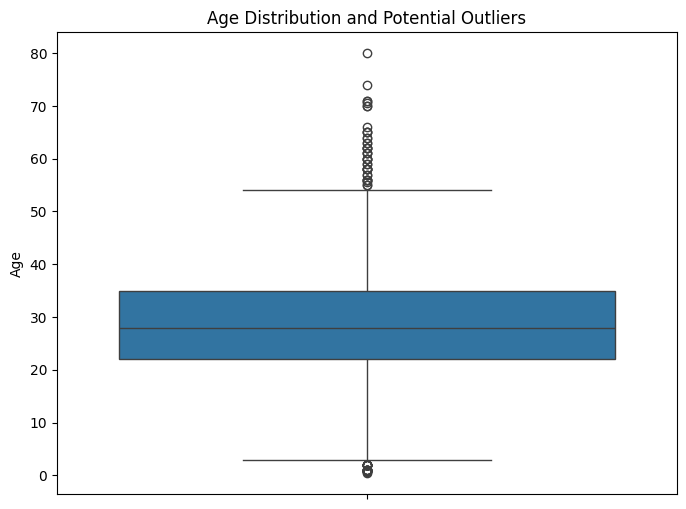

Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower Bound: 2.50
Upper Bound: 54.50
Number of potential Age outliers: 66


,Age,Survived
803,0.42,1
755,0.67,1
644,0.75,1
469,0.75,1
78,0.83,1
...,...,...
116,70.50,0
493,71.00,0
96,71.00,0
851,74.00,0


In [113]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=train_df_cleaned['Age'])
plt.title('Age Distribution and Potential Outliers')
plt.ylabel('Age')
plt.show()

# Calculate outlier boundaries using the IQR method
Q1_age = train_df_cleaned['Age'].quantile(0.25)
Q3_age = train_df_cleaned['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

age_lower_bound = Q1_age - 1.5 * IQR_age
age_upper_bound = Q3_age + 1.5 * IQR_age

# Identify potential Age outliers
age_outliers = train_df_cleaned[
    (train_df_cleaned['Age'] < age_lower_bound) |
    (train_df_cleaned['Age'] > age_upper_bound)
]

print(f"Q1: {Q1_age:.2f}")
print(f"Q3: {Q3_age:.2f}")
print(f"IQR: {IQR_age:.2f}")
print(f"Lower Bound: {age_lower_bound:.2f}")
print(f"Upper Bound: {age_upper_bound:.2f}")
print(f"Number of potential Age outliers: {len(age_outliers)}")

display(age_outliers[['Age', 'Survived']].sort_values('Age'))

The IQR method identified 66 potential outliers in the `Age` feature, consisting mainly of very young children and older passengers. These values are plausible passenger ages rather than apparent data errors. Therefore, the observations were retained without removal or capping.

### Fare

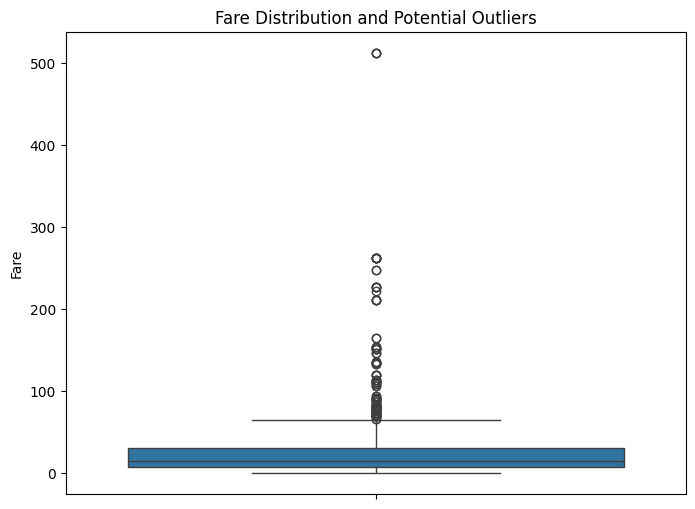

Q1: 7.91
Q3: 31.00
IQR: 23.09
Lower Bound: -26.72
Upper Bound: 65.63
Number of potential Fare outliers: 116


,Fare,Survived
258,512.3292,1
737,512.3292,1
679,512.3292,1
27,263.0000,0
341,263.0000,1
...,...,...
324,69.5500,0
369,69.3000,1
641,69.3000,1
336,66.6000,0


In [114]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=train_df_cleaned['Fare'])

plt.title('Fare Distribution and Potential Outliers')
plt.ylabel('Fare')
plt.show()

# Calculate outlier boundaries using the IQR method
Q1_fare = train_df_cleaned['Fare'].quantile(0.25)
Q3_fare = train_df_cleaned['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

fare_lower_bound = Q1_fare - 1.5 * IQR_fare
fare_upper_bound = Q3_fare + 1.5 * IQR_fare

# Identify potential Fare outliers
fare_outliers = train_df_cleaned[
    (train_df_cleaned['Fare'] < fare_lower_bound) |
    (train_df_cleaned['Fare'] > fare_upper_bound)
]

print(f"Q1: {Q1_fare:.2f}")
print(f"Q3: {Q3_fare:.2f}")
print(f"IQR: {IQR_fare:.2f}")
print(f"Lower Bound: {fare_lower_bound:.2f}")
print(f"Upper Bound: {fare_upper_bound:.2f}")
print(f"Number of potential Fare outliers: {len(fare_outliers)}")

display(
    fare_outliers[['Fare', 'Survived']]
    .sort_values('Fare', ascending=False)
)

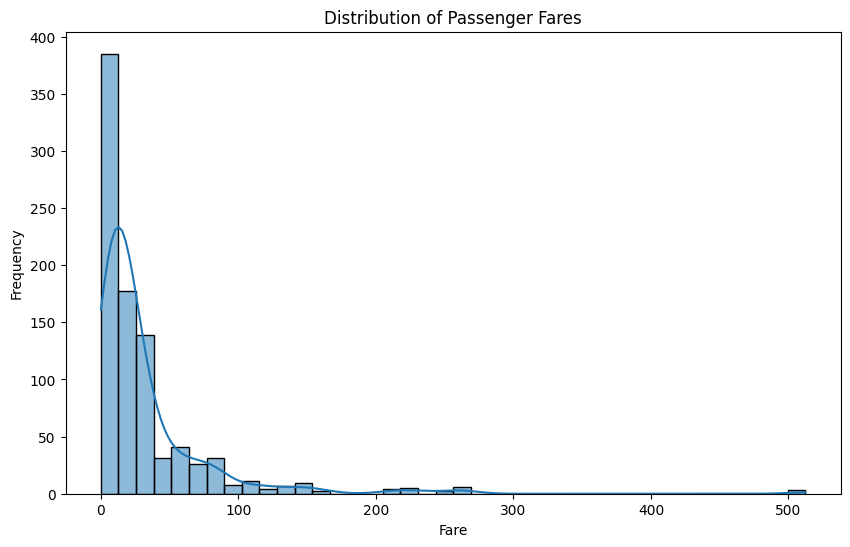

In [115]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df_cleaned['Fare'], bins=40, kde=True)

plt.title('Distribution of Passenger Fares')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

The `Fare` feature is strongly right-skewed, with 116 observations identified above the IQR upper bound. However, these higher fares represent plausible ticket prices rather than apparent data errors. Capping all values at the IQR threshold would substantially compress genuine variation in the feature. Therefore, the original fare values were retained at this stage, with transformation considered later during feature preparation.

# 5. Feature Engineering and Encoding

## 5.1 Title Extraction

In [116]:
import re

# Function to extract title from passenger name
def get_title(name):
    title_search = re.search(r' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

In [117]:
# Extract titles from passenger names
train_df_cleaned['Title'] = train_df_cleaned['Name'].apply(get_title)
test_df_cleaned['Title'] = test_df_cleaned['Name'].apply(get_title)

print("Training Data")
display(train_df_cleaned['Title'].value_counts())

print("Test Data")
display(test_df_cleaned['Title'].value_counts())

Training Data


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Test Data


,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [118]:
# Standardize equivalent titles
train_df_cleaned['Title'] = train_df_cleaned['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

test_df_cleaned['Title'] = test_df_cleaned['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# Group uncommon titles into a single Rare category
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col', 'Don',
    'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
]

train_df_cleaned['Title'] = train_df_cleaned['Title'].replace(
    rare_titles, 'Rare'
)

test_df_cleaned['Title'] = test_df_cleaned['Title'].replace(
    rare_titles, 'Rare'
)

print("Training Data")
display(train_df_cleaned['Title'].value_counts())

print("Test Data")
display(test_df_cleaned['Title'].value_counts())

Training Data


,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


Test Data


,count
Title,
Mr,240
Miss,79
Mrs,72
Master,21
Rare,6


In [119]:
# Drop the original Name column after extracting Title
train_df_cleaned.drop('Name', axis=1, inplace=True)
test_df_cleaned.drop('Name', axis=1, inplace=True)

## 5.2 Group & Family Features

In [120]:
# Create FamilySize feature
train_df_cleaned['FamilySize'] = (
    train_df_cleaned['SibSp'] + train_df_cleaned['Parch'] + 1
)

test_df_cleaned['FamilySize'] = (
    test_df_cleaned['SibSp'] + test_df_cleaned['Parch'] + 1
)

display(train_df_cleaned[['SibSp', 'Parch', 'FamilySize']].head(10))

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [121]:
# Create IsAlone feature
train_df_cleaned['IsAlone'] = np.where(
    train_df_cleaned['FamilySize'] == 1, 1, 0
)

test_df_cleaned['IsAlone'] = np.where(
    test_df_cleaned['FamilySize'] == 1, 1, 0
)

display(
    train_df_cleaned[
        ['SibSp', 'Parch', 'FamilySize', 'IsAlone']
    ].head(10)
)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [122]:
# Inspect the Ticket feature
print("Number of unique tickets:", train_df_cleaned['Ticket'].nunique())
print("Total passengers:", len(train_df_cleaned))

display(
    train_df_cleaned['Ticket']
    .value_counts()
    .head(10)
    .to_frame(name='Passenger Count')
)

Number of unique tickets: 681
Total passengers: 891


,Passenger Count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
347088,6
382652,5
S.O.C. 14879,5
113760,4


In [123]:
# Calculate how many passengers share each ticket in the training data
ticket_counts = train_df_cleaned['Ticket'].value_counts()

# Create TicketGroupSize
train_df_cleaned['TicketGroupSize'] = (
    train_df_cleaned['Ticket']
    .map(ticket_counts)
)

test_df_cleaned['TicketGroupSize'] = (
    test_df_cleaned['Ticket']
    .map(ticket_counts)
    .fillna(1)
    .astype(int)
)

display(
    train_df_cleaned[['Ticket', 'TicketGroupSize']]
    .sort_values('TicketGroupSize', ascending=False)
    .head(15)
)

,Ticket,TicketGroupSize
13,347082,7
324,CA. 2343,7
826,1601,7
813,347082,7
610,347082,7
201,CA. 2343,7
180,CA. 2343,7
169,1601,7
792,CA. 2343,7
74,1601,7


In [124]:
# Drop the original Ticket column after extracting TicketGroupSize
train_df_cleaned.drop('Ticket', axis=1, inplace=True)
test_df_cleaned.drop('Ticket', axis=1, inplace=True)

print("Training shape:", train_df_cleaned.shape)
print("Test shape:", test_df_cleaned.shape)

print("\n'Ticket' still present:", 'Ticket' in train_df_cleaned.columns)
print("'TicketGroupSize' present:", 'TicketGroupSize' in train_df_cleaned.columns)

Training shape: (891, 14)
Test shape: (418, 13)

'Ticket' still present: False
'TicketGroupSize' present: True


## 5.3 Categorical Encoding

In [125]:
# Encode Sex as a binary feature
sex_mapping = {
    'male': 0,
    'female': 1
}

train_df_cleaned['Sex_encoded'] = train_df_cleaned['Sex'].map(sex_mapping)
test_df_cleaned['Sex_encoded'] = test_df_cleaned['Sex'].map(sex_mapping)

display(
    train_df_cleaned[['Sex', 'Sex_encoded']]
    .drop_duplicates()
    .sort_values('Sex_encoded')
)


,Sex,Sex_encoded
0,male,0
1,female,1


In [126]:
# Check categories before one-hot encoding
for feature in ['Embarked', 'Title', 'Deck']:
    print(f"{feature}: {sorted(train_df_cleaned[feature].unique())}")

# Features to one-hot encode
features_to_onehot = ['Embarked', 'Title', 'Deck']

# Initialize the encoder
onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit the encoder on training data only
onehot_encoder.fit(train_df_cleaned[features_to_onehot])

# Transform both training and test data
train_onehot = onehot_encoder.transform(
    train_df_cleaned[features_to_onehot]
)

test_onehot = onehot_encoder.transform(
    test_df_cleaned[features_to_onehot]
)

print()
print("Encoded feature names:")
print(onehot_encoder.get_feature_names_out(features_to_onehot))

print("\nTraining encoded shape:", train_onehot.shape)
print("Test encoded shape:", test_onehot.shape)

# Convert encoded arrays into DataFrames
encoded_feature_names = onehot_encoder.get_feature_names_out(features_to_onehot)

train_onehot_df = pd.DataFrame(
    train_onehot,
    columns=encoded_feature_names,
    index=train_df_cleaned.index
)

test_onehot_df = pd.DataFrame(
    test_onehot,
    columns=encoded_feature_names,
    index=test_df_cleaned.index
)

display(train_onehot_df.head())

Embarked: ['C', 'Q', 'S']
Title: ['Master', 'Miss', 'Mr', 'Mrs', 'Rare']
Deck: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'Unknown']

Encoded feature names:
['Embarked_C' 'Embarked_Q' 'Embarked_S' 'Title_Master' 'Title_Miss'
 'Title_Mr' 'Title_Mrs' 'Title_Rare' 'Deck_A' 'Deck_B' 'Deck_C' 'Deck_D'
 'Deck_E' 'Deck_F' 'Deck_G' 'Deck_T' 'Deck_Unknown']

Training encoded shape: (891, 17)
Test encoded shape: (418, 17)


,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [127]:
# Add one-hot encoded features to the cleaned datasets
train_df_cleaned = pd.concat(
    [train_df_cleaned, train_onehot_df],
    axis=1
)

test_df_cleaned = pd.concat(
    [test_df_cleaned, test_onehot_df],
    axis=1
)

print("Training shape:", train_df_cleaned.shape)
print("Test shape:", test_df_cleaned.shape)

display(train_df_cleaned.head())

Training shape: (891, 32)
Test shape: (418, 31)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,1,1,female,38.0,1,0,71.2833,C,C,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,1,1,female,35.0,1,0,53.1000,S,C,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [128]:
# Drop original categorical columns after encoding
categorical_columns = ['Sex', 'Embarked', 'Title', 'Deck']

train_df_cleaned.drop(
    columns=categorical_columns,
    inplace=True
)

test_df_cleaned.drop(
    columns=categorical_columns,
    inplace=True
)

print("Training shape:", train_df_cleaned.shape)
print("Test shape:", test_df_cleaned.shape)

print("\nRemaining columns:")
print(train_df_cleaned.columns.tolist())

Training shape: (891, 28)
Test shape: (418, 27)

Remaining columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'Sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


In [129]:
# Drop PassengerId because it is an identifier
train_df_cleaned.drop('PassengerId', axis=1, inplace=True)
test_df_cleaned.drop('PassengerId', axis=1, inplace=True)

print("Training shape:", train_df_cleaned.shape)
print("Test shape:", test_df_cleaned.shape)

print("\nRemaining columns:")
print(train_df_cleaned.columns.tolist())

Training shape: (891, 27)
Test shape: (418, 26)

Remaining columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'Sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


# 6. Exploratory Data Analysis

## 6.1 Survival Distribution

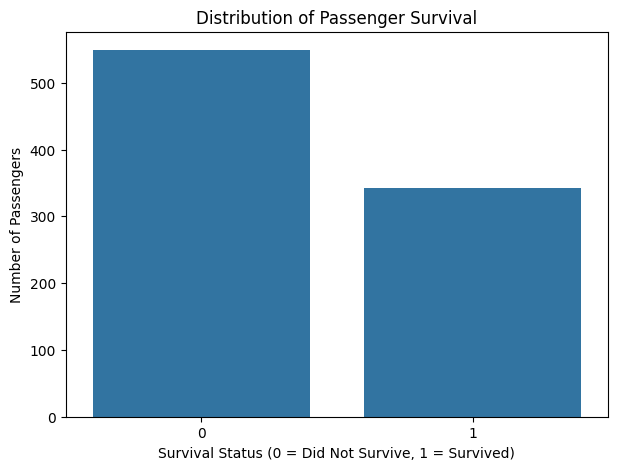

Survival counts:


,Passenger Count
Survived,
0,549
1,342


Survival percentages:


,Percentage (%)
Survived,
0,61.62
1,38.38


In [131]:
# Examine the distribution of the target variable
survival_counts = train_df['Survived'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Survived')
plt.title('Distribution of Passenger Survival')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()

print("Survival counts:")
display(survival_counts.to_frame(name='Passenger Count'))

print("Survival percentages:")
display(
    (train_df['Survived'].value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2))
    .to_frame(name='Percentage (%)')
)

The target variable shows a moderate class imbalance, with 61.62% of passengers not surviving and 38.38% surviving. This imbalance should be considered during model training and evaluation, particularly when selecting appropriate performance metrics.

## 6.2 Survival by Sex

In [132]:
# Calculate survival rate by sex
survival_by_sex = (
    train_df.groupby('Sex')['Survived']
    .agg(['count', 'sum', 'mean'])
)

survival_by_sex.columns = [
    'Passenger Count',
    'Survivors',
    'Survival Rate'
]

survival_by_sex['Survival Rate'] = (
    survival_by_sex['Survival Rate'] * 100
).round(2)

display(survival_by_sex)

,Passenger Count,Survivors,Survival Rate
Sex,,,
female,314,233,74.20
male,577,109,18.89


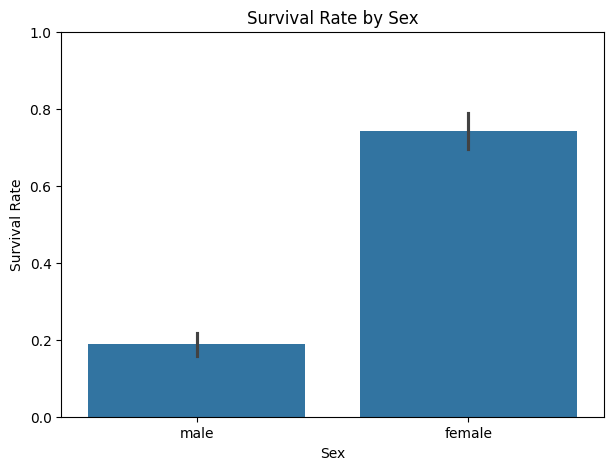

In [133]:
# Visualize survival rate by sex
plt.figure(figsize=(7, 5))

sns.barplot(
    data=train_df,
    x='Sex',
    y='Survived'
)

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.show()

Female passengers had a substantially higher survival rate (74.20%) than male passengers (18.89%). This indicates a strong association between sex and survival in the training dataset, suggesting that sex may be an important predictive feature.

## 6.3 Survival by Passenger Class

In [134]:
# Calculate survival rate by passenger class
survival_by_class = (
    train_df.groupby('Pclass')['Survived']
    .agg(['count', 'sum', 'mean'])
)

survival_by_class.columns = [
    'Passenger Count',
    'Survivors',
    'Survival Rate'
]

survival_by_class['Survival Rate'] = (
    survival_by_class['Survival Rate'] * 100
).round(2)

display(survival_by_class)

,Passenger Count,Survivors,Survival Rate
Pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24


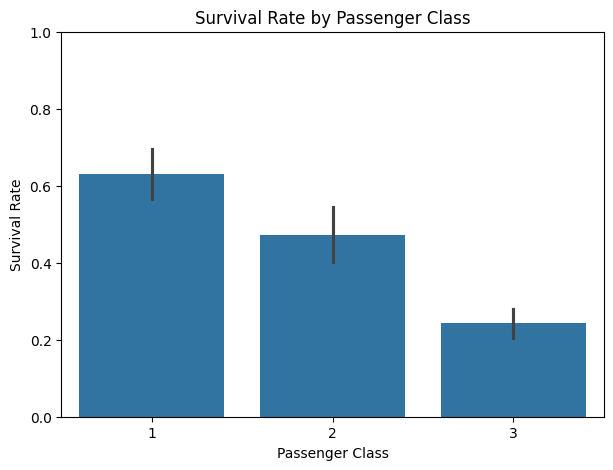

In [135]:
# Visualize survival rate by passenger class
plt.figure(figsize=(7, 5))

sns.barplot(
    data=train_df,
    x='Pclass',
    y='Survived'
)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.show()

Passenger class was associated with survival outcomes. First-class passengers had the highest survival rate (62.96%), followed by second-class passengers (47.28%), while third-class passengers had the lowest survival rate (24.24%). This suggests that passenger class may be an important predictive feature.

## 6.4 Age and Survival

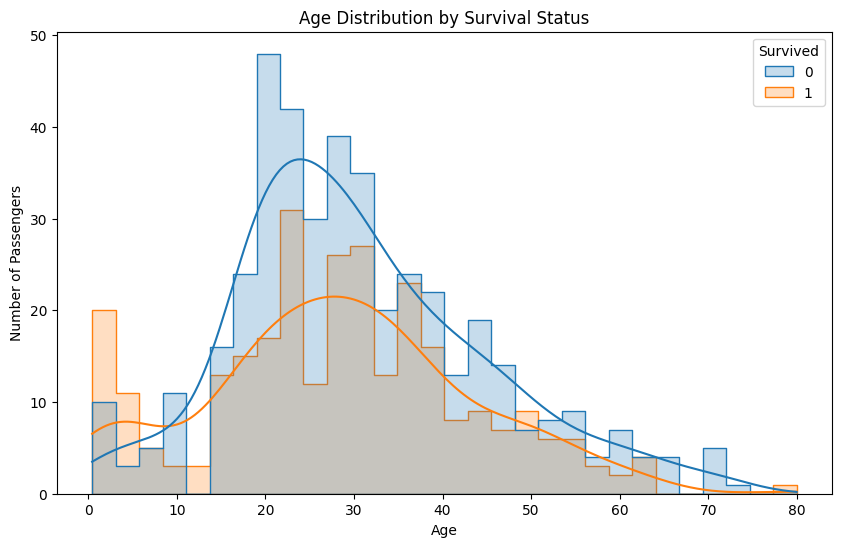

In [137]:
# Compare age distributions by survival status
plt.figure(figsize=(10, 6))

sns.histplot(
    data=train_df,
    x='Age',
    hue='Survived',
    bins=30,
    kde=True,
    element='step'
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

The age distributions of survivors and non-survivors overlap considerably, suggesting that age alone does not clearly separate the two groups. However, younger children appear to have a relatively higher representation among survivors. Overall, age may provide useful predictive information when considered alongside other passenger characteristics.

## 6.5 Fare and Survival

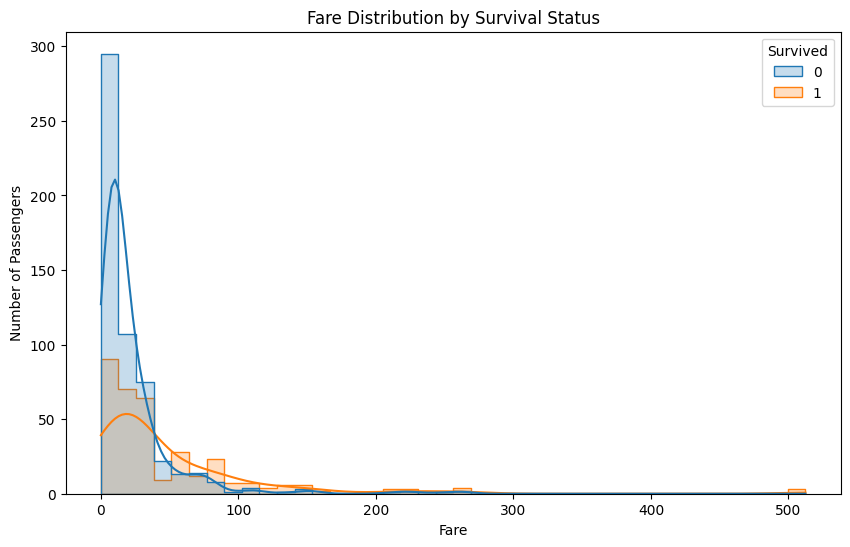

In [138]:
# Compare fare distributions by survival status
plt.figure(figsize=(10, 6))

sns.histplot(
    data=train_df,
    x='Fare',
    hue='Survived',
    bins=40,
    kde=True,
    element='step'
)

plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')

plt.show()

The fare distribution is strongly right-skewed, with most passengers paying relatively low fares and a small number paying substantially higher amounts. Non-survivors are more concentrated within the lower fare range, while survivors show relatively greater representation at higher fares. This suggests an association between fare and survival, although the distributions overlap considerably.

## 6.6 Survival by Family Size

In [139]:
# Calculate survival rate by family size
survival_by_family = (
    train_df_cleaned.groupby('FamilySize')['Survived']
    .agg(['count', 'sum', 'mean'])
)

survival_by_family.columns = [
    'Passenger Count',
    'Survivors',
    'Survival Rate'
]

survival_by_family['Survival Rate'] = (
    survival_by_family['Survival Rate'] * 100
).round(2)

display(survival_by_family)

,Passenger Count,Survivors,Survival Rate
FamilySize,,,
1,537,163,30.35
2,161,89,55.28
3,102,59,57.84
4,29,21,72.41
5,15,3,20.00
6,22,3,13.64
7,12,4,33.33
8,6,0,0.00
11,7,0,0.00


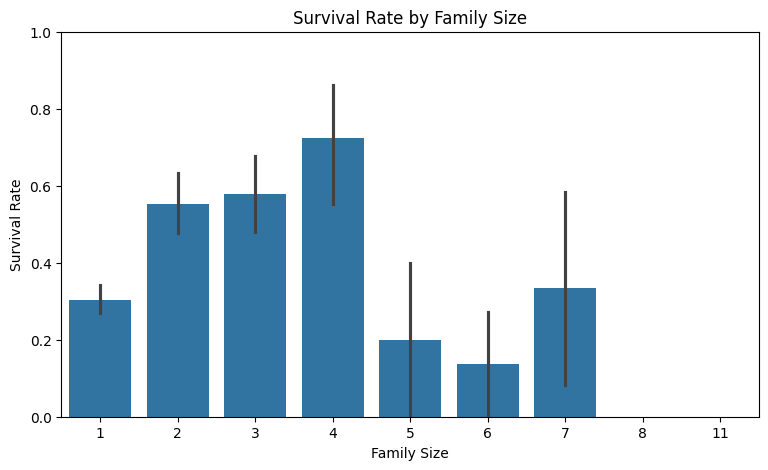

In [140]:
# Visualize survival rate by family size
plt.figure(figsize=(9, 5))

sns.barplot(
    data=train_df_cleaned,
    x='FamilySize',
    y='Survived'
)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.show()

Passengers travelling in small family groups generally had higher survival rates than those travelling alone. Larger family groups showed lower survival rates, although these groups contained relatively few passengers and should therefore be interpreted cautiously. Overall, the pattern suggests that family size may provide useful information beyond the original `SibSp` and `Parch` features.

## 6.7 Survival by Travelling Status

In [141]:
# Calculate survival rate by travelling status
survival_by_alone = (
    train_df_cleaned.groupby('IsAlone')['Survived']
    .agg(['count', 'sum', 'mean'])
)

survival_by_alone.columns = [
    'Passenger Count',
    'Survivors',
    'Survival Rate'
]

survival_by_alone.index = survival_by_alone.index.map({
    0: 'With Family',
    1: 'Alone'
})

survival_by_alone['Survival Rate'] = (
    survival_by_alone['Survival Rate'] * 100
).round(2)

display(survival_by_alone)

,Passenger Count,Survivors,Survival Rate
IsAlone,,,
With Family,354,179,50.56
Alone,537,163,30.35


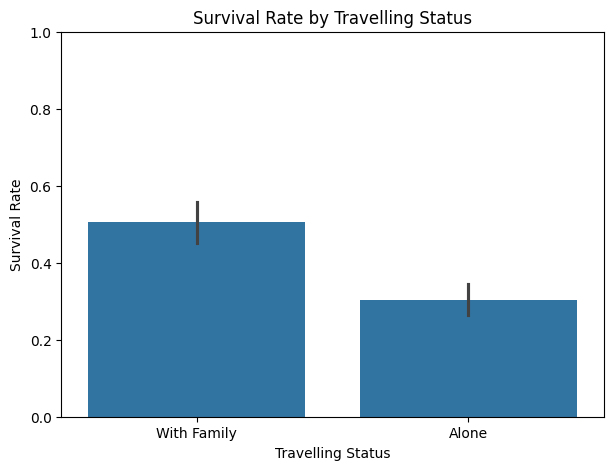

In [142]:
# Visualize survival rate by travelling status
plt.figure(figsize=(7, 5))

sns.barplot(
    data=train_df_cleaned,
    x='IsAlone',
    y='Survived'
)

plt.title('Survival Rate by Travelling Status')
plt.xlabel('Travelling Status')
plt.ylabel('Survival Rate')
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.ylim(0, 1)

plt.show()

Passengers travelling with family had a higher survival rate (50.56%) than passengers travelling alone (30.35%). This indicates an association between travelling status and survival and supports the inclusion of `IsAlone` as an engineered feature.

## 6.8 Survival by Ticket Group Size

In [143]:
# Calculate survival rate by ticket group size
survival_by_ticket_group = (
    train_df_cleaned.groupby('TicketGroupSize')['Survived']
    .agg(['count', 'sum', 'mean'])
)

survival_by_ticket_group.columns = [
    'Passenger Count',
    'Survivors',
    'Survival Rate'
]

survival_by_ticket_group['Survival Rate'] = (
    survival_by_ticket_group['Survival Rate'] * 100
).round(2)

display(survival_by_ticket_group)

,Passenger Count,Survivors,Survival Rate
TicketGroupSize,,,
1,547,163,29.80
2,188,108,57.45
3,63,44,69.84
4,44,22,50.00
5,10,0,0.00
6,18,0,0.00
7,21,5,23.81


Passengers sharing tickets in small groups generally had higher survival rates than passengers with unique tickets. In particular, ticket groups of two to four passengers showed relatively higher survival rates. Larger ticket groups showed lower survival rates, although these categories contained fewer passengers and should be interpreted cautiously. This pattern suggests that `TicketGroupSize` captures potentially useful group-travel information from the original `Ticket` feature.

## 6.9 Feature Correlation Analysis

In [146]:
# Calculate correlations with the target variable
survival_correlations = (
    train_df_cleaned
    .corr(numeric_only=True)['Survived']
    .drop('Survived')
    .sort_values(ascending=False)
)

display(
    survival_correlations
    .to_frame(name='Correlation with Survived')
)

,Correlation with Survived
Sex_encoded,0.543351
Title_Mrs,0.341994
Title_Miss,0.335636
Fare,0.257307
Deck_B,0.175095
Embarked_C,0.168240
Deck_D,0.150716
Deck_E,0.145321
Deck_C,0.114652
Title_Master,0.085221


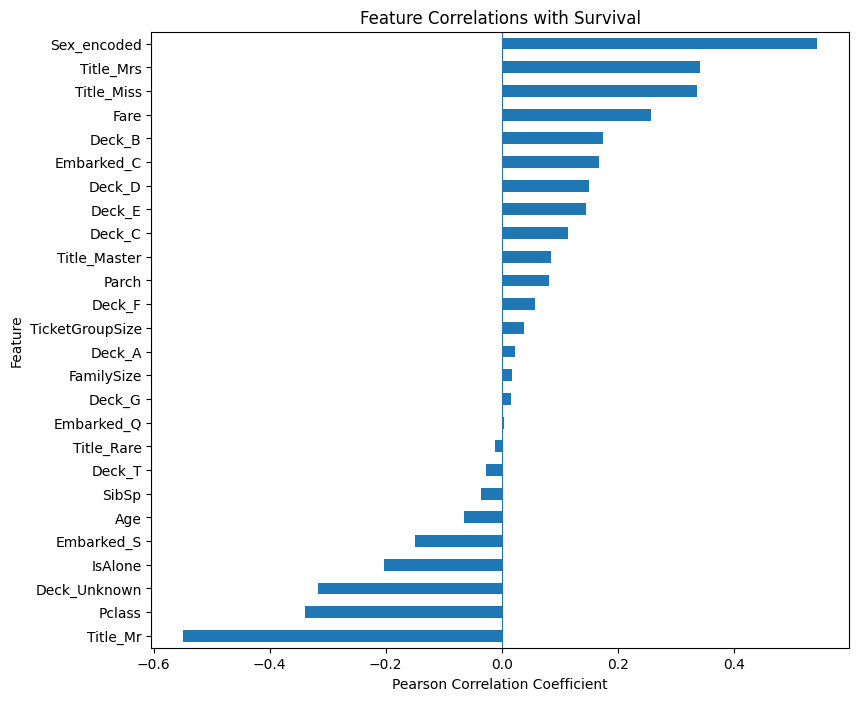

In [145]:
# Visualize feature correlations with survival
plt.figure(figsize=(9, 8))

survival_correlations.sort_values().plot(kind='barh')

plt.title('Feature Correlations with Survival')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, linewidth=0.8)

plt.show()

Sex showed one of the strongest associations with survival, with `Sex_encoded` having a positive correlation of 0.543. Since female passengers were encoded as 1, this is consistent with the higher survival rate observed among female passengers. The title-based features showed a similar pattern, with `Title_Mrs` and `Title_Miss` positively correlated with survival, while `Title_Mr` showed a strong negative correlation.

`Pclass` was negatively correlated with survival (-0.338), indicating lower survival rates as the numerical class value increased from first to third class. `Fare` showed a moderate positive correlation (0.257), which is also consistent with the earlier exploratory analysis.

Some engineered features, such as `FamilySize` and `TicketGroupSize`, showed weak linear correlations with survival despite displaying meaningful patterns during the earlier group-based analysis. This highlights that Pearson correlation captures only linear relationships and should not be used alone to determine whether a feature is useful for prediction.

# 7. Model Preparation

The processed dataset is prepared for model development by separating the predictor variables from the target variable and creating training and validation subsets. The validation set will be used to evaluate model performance on unseen observations.

## 7.1 Separating Features and Target

In [147]:
# Separate predictor variables and target variable
X = train_df_cleaned.drop('Survived', axis=1)
y = train_df_cleaned['Survived']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (891, 26)
Target vector shape: (891,)


## 7.2 Train-Validation Split

In [148]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

Training features shape: (712, 26)
Validation features shape: (179, 26)
Training target shape: (712,)
Validation target shape: (179,)


In [149]:
# Verify class distribution after stratified splitting
print("Training set class distribution:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame(name='Percentage (%)')
)

print("Validation set class distribution:")
display(
    y_val.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame(name='Percentage (%)')
)

Training set class distribution:


,Percentage (%)
Survived,
0,61.66
1,38.34


Validation set class distribution:


,Percentage (%)
Survived,
0,61.45
1,38.55


The stratified split successfully preserved the original class distribution in both the training and validation sets. This ensures that both subsets contain representative proportions of survivors and non-survivors.

## 7.3 Feature Scaling

In [152]:
features_to_scale = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize',
    'TicketGroupSize'
]

# Create copies for scaled model inputs
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

# Initialize the scaler
scaler = StandardScaler()

# Fit only on the training data
X_train_scaled[features_to_scale] = scaler.fit_transform(
    X_train[features_to_scale]
)

# Use the training-fitted scaler to transform validation data
X_val_scaled[features_to_scale] = scaler.transform(
    X_val[features_to_scale]
)

display(
    X_train_scaled[features_to_scale]
    .agg(['mean', 'std'])
    .round(3)
)

,Age,Fare,SibSp,Parch,FamilySize,TicketGroupSize
mean,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001


The selected numerical features were standardized using `StandardScaler`. The scaler was fitted exclusively on the training data and subsequently applied to the validation data to prevent information from the validation set from influencing the scaling process. The resulting training features have means approximately equal to 0 and standard deviations approximately equal to 1.

# 8. Model Development and Evaluation

## 8.1 Logistic Regression

Accuracy:  0.8268
Precision: 0.7568
Recall:    0.8116
F1-Score:  0.7832
ROC-AUC:   0.8735

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.88      0.84      0.86       110
       Survived       0.76      0.81      0.78        69

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



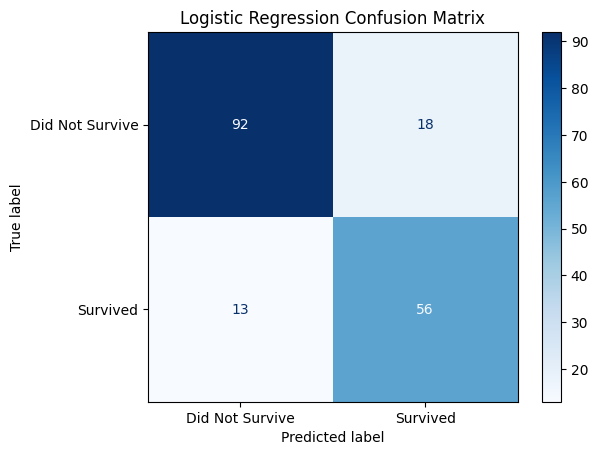

In [157]:
# Initialize Logistic Regression
logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_val_scaled)

# Generate predicted probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_val_scaled)[:, 1]

# Evaluate Logistic Regression
logistic_accuracy = accuracy_score(y_val, y_pred_logistic)
logistic_precision = precision_score(y_val, y_pred_logistic)
logistic_recall = recall_score(y_val, y_pred_logistic)
logistic_f1 = f1_score(y_val, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_val, y_prob_logistic)

print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")
print()

# Display classification report
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_pred_logistic,
        target_names=['Did Not Survive', 'Survived']
    )
)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_logistic,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()

The Logistic Regression model achieved an accuracy of 82.68%, with an F1-score of 0.7832 and a ROC-AUC of 0.8735. Its recall of 81.16% indicates that the model successfully identified a relatively high proportion of passengers who survived.

The confusion matrix shows that 92 non-survivors and 56 survivors were classified correctly, while 18 non-survivors were incorrectly classified as survivors and 13 survivors were missed. Overall, the model provides a useful baseline with a reasonable balance between precision and recall.

## 8.2 Random Forest

Accuracy:  0.7877
Precision: 0.7460
Recall:    0.6812
F1-Score:  0.7121
ROC-AUC:   0.8179

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.85      0.83       110
       Survived       0.75      0.68      0.71        69

       accuracy                           0.79       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.79      0.79      0.79       179



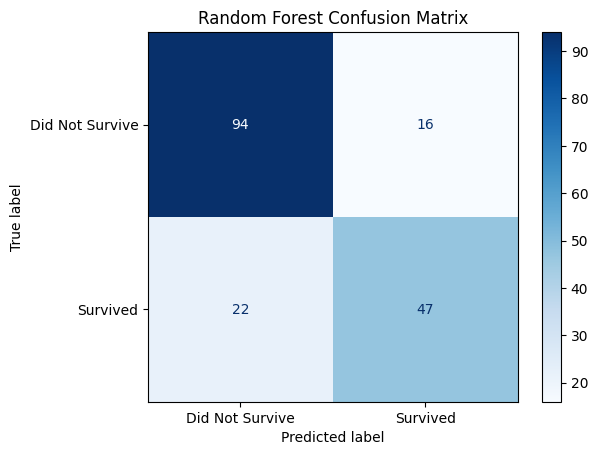

In [162]:
# Initialize Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = random_forest_model.predict(X_val)

# Generate predicted probabilities for ROC-AUC
y_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf)
rf_recall = recall_score(y_val, y_pred_rf)
rf_f1 = f1_score(y_val, y_pred_rf)
rf_roc_auc = roc_auc_score(y_val, y_prob_rf)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print()

# Display classification report
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_pred_rf,
        target_names=['Did Not Survive', 'Survived']
    )
)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

The Random Forest model achieved an accuracy of 78.77%, with an F1-score of 0.7121 and a ROC-AUC of 0.8179. Its recall of 68.12% indicates that the model identified approximately two-thirds of the passengers who actually survived.

The confusion matrix shows that 94 non-survivors and 47 survivors were classified correctly, while 16 non-survivors were incorrectly classified as survivors and 22 survivors were missed. Compared with Logistic Regression, the Random Forest model showed lower recall and overall validation performance in this baseline configuration.

## 8.3 Multilayer Perceptron (MLP)

Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-Score:  0.7287
ROC-AUC:   0.8353

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.78      0.68      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



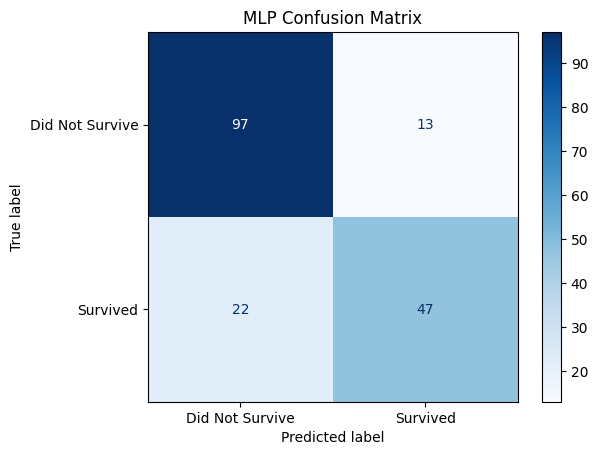

In [167]:
# Initialize MLP classifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Train the model
mlp_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_mlp = mlp_model.predict(X_val_scaled)

# Generate predicted probabilities for ROC-AUC
y_prob_mlp = mlp_model.predict_proba(X_val_scaled)[:, 1]

# Evaluate MLP
mlp_accuracy = accuracy_score(y_val, y_pred_mlp)
mlp_precision = precision_score(y_val, y_pred_mlp)
mlp_recall = recall_score(y_val, y_pred_mlp)
mlp_f1 = f1_score(y_val, y_pred_mlp)
mlp_roc_auc = roc_auc_score(y_val, y_prob_mlp)

print(f"Accuracy:  {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall:    {mlp_recall:.4f}")
print(f"F1-Score:  {mlp_f1:.4f}")
print(f"ROC-AUC:   {mlp_roc_auc:.4f}")
print()

# Display classification report
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_pred_mlp,
        target_names=['Did Not Survive', 'Survived']
    )
)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_mlp,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('MLP Confusion Matrix')
plt.show()

The MLP model achieved an accuracy of 80.45%, with an F1-score of 0.7287 and a ROC-AUC of 0.8353. Its precision of 78.33% indicates that a relatively high proportion of passengers predicted to survive were correctly classified. However, its recall of 68.12% shows that the model missed a larger proportion of actual survivors.

The confusion matrix shows that 97 non-survivors and 47 survivors were classified correctly, while 13 non-survivors were incorrectly classified as survivors and 22 survivors were missed. Overall, the MLP demonstrated reasonable predictive performance but showed a greater tendency to miss survivors compared with Logistic Regression.

## 8.4 Baseline Model Comparison

In [168]:
# Create model comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'MLP'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy,
        mlp_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision,
        mlp_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall,
        mlp_recall
    ],
    'F1-Score': [
        logistic_f1,
        rf_f1,
        mlp_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        rf_roc_auc,
        mlp_roc_auc
    ]
})

model_comparison = model_comparison.set_index('Model')

display(model_comparison.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8268,0.7568,0.8116,0.7832,0.8735
Random Forest,0.7877,0.7460,0.6812,0.7121,0.8179
MLP,0.8045,0.7833,0.6812,0.7287,0.8353


# 9. Model Improvement and Robust Validation

The initial model comparison was conducted using a stratified holdout validation set. However, several preprocessing steps had been fitted to the full training dataset before the train-validation split. Although the separate Kaggle test dataset remained unseen, this could allow information from the internal validation subset to influence preprocessing and produce an overly optimistic estimate of validation performance.

To obtain a more rigorous evaluation, the preprocessing and feature preparation workflow is subsequently refitted using only the internal training subset, with the learned transformations then applied to the validation subset.

## 9.1 Leakage-Safe Data Preparation

In [176]:
# Separate the target from the original, unprocessed dataset
X_raw = train_df.drop('Survived', axis=1)
y_raw = train_df['Survived']

# Split before learning any preprocessing parameters
X_train_raw, X_val_raw, y_train_robust, y_val_robust = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

print("Training set:", X_train_raw.shape)
print("Validation set:", X_val_raw.shape)

Training set: (712, 11)
Validation set: (179, 11)


### Preprocessing Function

In [177]:
def preprocess_titanic_data(train_data, validation_data):
    """
    Preprocess Titanic training and validation data while ensuring that
    learned preprocessing parameters are derived from the training data only.
    """

    train = train_data.copy()
    validation = validation_data.copy()

    # --------------------------------------------------
    # 1. Missing value handling
    # --------------------------------------------------
    age_median = train['Age'].median()
    embarked_mode = train['Embarked'].mode()[0]
    fare_median = train['Fare'].median()

    train['Age'] = train['Age'].fillna(age_median)
    validation['Age'] = validation['Age'].fillna(age_median)

    train['Embarked'] = train['Embarked'].fillna(embarked_mode)
    validation['Embarked'] = validation['Embarked'].fillna(embarked_mode)

    train['Fare'] = train['Fare'].fillna(fare_median)
    validation['Fare'] = validation['Fare'].fillna(fare_median)

    # --------------------------------------------------
    # 2. Extract Deck from Cabin
    # --------------------------------------------------
    train['Deck'] = train['Cabin'].apply(
        lambda x: x[0] if pd.notnull(x) else 'Unknown'
    )
    validation['Deck'] = validation['Cabin'].apply(
        lambda x: x[0] if pd.notnull(x) else 'Unknown'
    )

    # --------------------------------------------------
    # 3. Extract and standardize passenger titles
    # --------------------------------------------------
    train['Title'] = train['Name'].apply(get_title)
    validation['Title'] = validation['Name'].apply(get_title)

    title_replacements = {
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs'
    }

    train['Title'] = train['Title'].replace(title_replacements)
    validation['Title'] = validation['Title'].replace(title_replacements)

    rare_titles = [
        'Lady', 'Countess', 'Capt', 'Col', 'Don',
        'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
    ]

    train['Title'] = train['Title'].replace(rare_titles, 'Rare')
    validation['Title'] = validation['Title'].replace(rare_titles, 'Rare')

    # --------------------------------------------------
    # 4. Family features
    # --------------------------------------------------
    train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
    validation['FamilySize'] = (
        validation['SibSp'] + validation['Parch'] + 1
    )

    train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
    validation['IsAlone'] = (
        validation['FamilySize'] == 1
    ).astype(int)

    # --------------------------------------------------
    # 5. Ticket group size
    # Learn ticket frequencies from training data only
    # --------------------------------------------------
    ticket_counts = train['Ticket'].value_counts()

    train['TicketGroupSize'] = train['Ticket'].map(ticket_counts)

    validation['TicketGroupSize'] = (
        validation['Ticket']
        .map(ticket_counts)
        .fillna(1)
        .astype(int)
    )

    # --------------------------------------------------
    # 6. Encode Sex
    # --------------------------------------------------
    sex_mapping = {'male': 0, 'female': 1}

    train['Sex_encoded'] = train['Sex'].map(sex_mapping)
    validation['Sex_encoded'] = validation['Sex'].map(sex_mapping)

    # --------------------------------------------------
    # 7. One-hot encode categorical features
    # --------------------------------------------------
    categorical_features = ['Embarked', 'Title', 'Deck']

    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

    train_encoded = encoder.fit_transform(
        train[categorical_features]
    )

    validation_encoded = encoder.transform(
        validation[categorical_features]
    )

    encoded_columns = encoder.get_feature_names_out(
        categorical_features
    )

    train_encoded = pd.DataFrame(
        train_encoded,
        columns=encoded_columns,
        index=train.index
    )

    validation_encoded = pd.DataFrame(
        validation_encoded,
        columns=encoded_columns,
        index=validation.index
    )

    train = pd.concat([train, train_encoded], axis=1)
    validation = pd.concat(
        [validation, validation_encoded],
        axis=1
    )

    # --------------------------------------------------
    # 8. Remove unused original columns
    # --------------------------------------------------
    columns_to_drop = [
        'PassengerId',
        'Name',
        'Sex',
        'Ticket',
        'Cabin',
        'Embarked',
        'Title',
        'Deck'
    ]

    train.drop(columns=columns_to_drop, inplace=True)
    validation.drop(columns=columns_to_drop, inplace=True)

    return train, validation

In [178]:
# Apply leakage-safe preprocessing
X_train_robust, X_val_robust = preprocess_titanic_data(
    X_train_raw,
    X_val_raw
)

print("Processed training shape:", X_train_robust.shape)
print("Processed validation shape:", X_val_robust.shape)

print("\nMissing values:")
print("Training:", X_train_robust.isna().sum().sum())
print("Validation:", X_val_robust.isna().sum().sum())

print("\nSame feature columns:",
      X_train_robust.columns.equals(X_val_robust.columns))

print("\nFeatures:")
print(X_train_robust.columns.tolist())

Processed training shape: (712, 26)
Processed validation shape: (179, 26)

Missing values:
Training: 0
Validation: 0

Same feature columns: True

Features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'Sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


In [179]:
# Scale numerical features using training data only
features_to_scale_robust = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize',
    'TicketGroupSize'
]

X_train_robust_scaled = X_train_robust.copy()
X_val_robust_scaled = X_val_robust.copy()

scaler_robust = StandardScaler()

X_train_robust_scaled[features_to_scale_robust] = (
    scaler_robust.fit_transform(
        X_train_robust[features_to_scale_robust]
    )
)

X_val_robust_scaled[features_to_scale_robust] = (
    scaler_robust.transform(
        X_val_robust[features_to_scale_robust]
    )
)

X_train_robust_scaled[features_to_scale_robust].agg(['mean', 'std']).round(3)

,Age,Fare,SibSp,Parch,FamilySize,TicketGroupSize
mean,0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001


## 9.2 Random Forest Hyperparameter Tuning

The baseline Random Forest model was trained using a fixed set of parameters. To improve its predictive performance and reduce the risk of relying on a single parameter configuration, hyperparameter tuning is performed using cross-validation on the leakage-safe training data.

Hyperparameter tuning was performed using 5-fold cross-validation on the training subset only. The held-out validation set was not used during hyperparameter selection and was reserved exclusively for the final evaluation of the tuned model.

In [180]:
from sklearn.model_selection import GridSearchCV

# Define Random Forest model
rf_tuning_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Define hyperparameter search space
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform 5-fold cross-validation
rf_grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid_search.fit(
    X_train_robust,
    y_train_robust
)

print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(rf_grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1-Score:
0.768


Accuracy:  0.8101
Precision: 0.7612
Recall:    0.7391
F1-Score:  0.7500
ROC-AUC:   0.8529
Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.85      0.85       110
       Survived       0.76      0.74      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



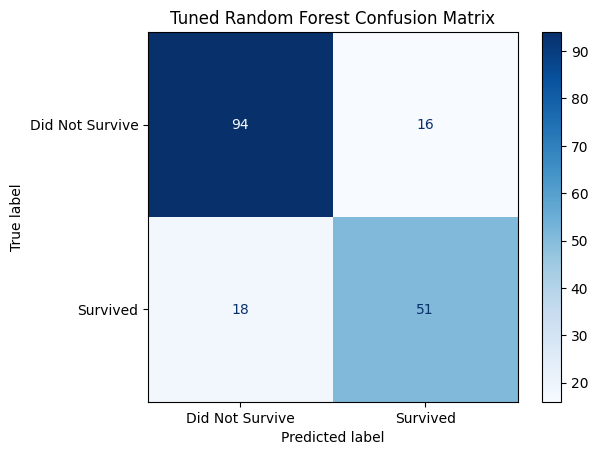

In [182]:
# Retrieve the best Random Forest model
best_rf_model = rf_grid_search.best_estimator_

# Generate validation predictions
y_pred_rf_tuned = best_rf_model.predict(X_val_robust)
y_prob_rf_tuned = best_rf_model.predict_proba(X_val_robust)[:, 1]

# Calculate evaluation metrics
rf_tuned_accuracy = accuracy_score(y_val_robust, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_val_robust, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_val_robust, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_val_robust, y_pred_rf_tuned)
rf_tuned_roc_auc = roc_auc_score(y_val_robust, y_prob_rf_tuned)

print(f"Accuracy:  {rf_tuned_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall:    {rf_tuned_recall:.4f}")
print(f"F1-Score:  {rf_tuned_f1:.4f}")
print(f"ROC-AUC:   {rf_tuned_roc_auc:.4f}")

print("Classification Report:")
print(
    classification_report(
        y_val_robust,
        y_pred_rf_tuned,
        target_names=['Did Not Survive', 'Survived']
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_val_robust,
    y_pred_rf_tuned,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

The tuned Random Forest achieved an accuracy of 81.01%, with a precision of 76.12%, recall of 73.91%, F1-score of 0.7500, and ROC-AUC of 0.8529.

Compared with the baseline Random Forest, hyperparameter tuning improved all five evaluation metrics. In particular, recall increased from 68.12% to 73.91%, reducing the number of missed survivors from 22 to 18. The F1-score also improved from 0.7121 to 0.7500, indicating a better balance between precision and recall.

Overall, the results suggest that hyperparameter tuning improved the Random Forest model's generalization performance on the held-out validation set.

## 9.3 MLP Model Improvement

The baseline MLP used a relatively simple neural network configuration. To explore whether a more structured neural network can improve predictive performance, an enhanced MLP architecture is developed using multiple hidden layers and regularization.

The leakage-safe scaled training data is used for model training, while the held-out validation set remains separate for final evaluation.

In [185]:
# Set TensorFlow random seed for reproducibility
tf.random.set_seed(42)

# Build the improved MLP model
improved_mlp_model = Sequential([
    Input(shape=(X_train_robust_scaled.shape[1],)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dropout(0.4),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

improved_mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

improved_mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights using training labels only
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_robust),
    y=y_train_robust
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class Weights:", class_weight_dict)

# Configure early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the improved MLP
mlp_history = improved_mlp_model.fit(
    X_train_robust_scaled,
    y_train_robust,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Class Weights: {0: np.float64(0.8109339407744874), 1: np.float64(1.304029304029304)}
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5413 - loss: 0.7280 - val_accuracy: 0.6643 - val_loss: 0.6683
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5940 - loss: 0.6750 - val_accuracy: 0.7063 - val_loss: 0.6450
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6257 - loss: 0.6772 - val_accuracy: 0.7413 - val_loss: 0.6276
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6415 - loss: 0.6514 - val_accuracy: 0.7343 - val_loss: 0.5998
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6678 - loss: 0.6271 - val_accuracy: 0.7692 - val_loss: 0.5677
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6977 - loss: 0.6058 - val_accuracy: 0.7972 - val_loss: 0.5305
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7188 - loss: 0.5915 - val_accuracy: 0.8042 - val_loss: 0.5109
Epoch 8/100
36/36 ━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy:  0.8268
Precision: 0.7714
Recall:    0.7826
F1-Score:  0.7770
ROC-AUC:   0.8592
Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.86      0.85      0.86       110
       Survived       0.77      0.78      0.78        69

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



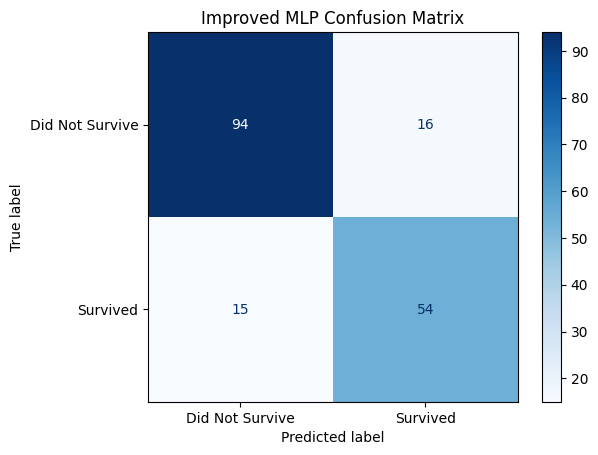

In [189]:
# Generate probability predictions
y_prob_mlp_improved = improved_mlp_model.predict(
    X_val_robust_scaled
).ravel()

# Convert probabilities to binary predictions
y_pred_mlp_improved = (
    y_prob_mlp_improved >= 0.5
).astype(int)

# Calculate evaluation metrics
mlp_improved_accuracy = accuracy_score(
    y_val_robust,
    y_pred_mlp_improved
)

mlp_improved_precision = precision_score(
    y_val_robust,
    y_pred_mlp_improved
)

mlp_improved_recall = recall_score(
    y_val_robust,
    y_pred_mlp_improved
)

mlp_improved_f1 = f1_score(
    y_val_robust,
    y_pred_mlp_improved
)

mlp_improved_roc_auc = roc_auc_score(
    y_val_robust,
    y_prob_mlp_improved
)

print(f"Accuracy:  {mlp_improved_accuracy:.4f}")
print(f"Precision: {mlp_improved_precision:.4f}")
print(f"Recall:    {mlp_improved_recall:.4f}")
print(f"F1-Score:  {mlp_improved_f1:.4f}")
print(f"ROC-AUC:   {mlp_improved_roc_auc:.4f}")

print("Classification Report:")
print(
    classification_report(
        y_val_robust,
        y_pred_mlp_improved,
        target_names=['Did Not Survive', 'Survived']
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_val_robust,
    y_pred_mlp_improved,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues'
)

plt.title('Improved MLP Confusion Matrix')
plt.show()

The improved MLP achieved an accuracy of 82.68%, with a precision of 77.14%, recall of 78.26%, F1-score of 0.7770, and ROC-AUC of 0.8592.

Compared with the baseline MLP, the improved architecture substantially increased recall from 68.12% to 78.26% and improved the F1-score from 0.7287 to 0.7770. The number of missed survivors decreased from 22 to 15, although this was accompanied by a small increase in false-positive predictions.

Overall, the deeper architecture, dropout regularization, class weighting, and early stopping produced a better balance between identifying survivors and maintaining prediction precision.

## 9.4 Logistic Regression Re-evaluation

In [190]:
# Train Logistic Regression using leakage-safe scaled data
logistic_robust_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logistic_robust_model.fit(
    X_train_robust_scaled,
    y_train_robust
)

# Generate validation predictions
y_pred_logistic_robust = logistic_robust_model.predict(
    X_val_robust_scaled
)

y_prob_logistic_robust = logistic_robust_model.predict_proba(
    X_val_robust_scaled
)[:, 1]

# Calculate evaluation metrics
logistic_robust_accuracy = accuracy_score(
    y_val_robust,
    y_pred_logistic_robust
)

logistic_robust_precision = precision_score(
    y_val_robust,
    y_pred_logistic_robust
)

logistic_robust_recall = recall_score(
    y_val_robust,
    y_pred_logistic_robust
)

logistic_robust_f1 = f1_score(
    y_val_robust,
    y_pred_logistic_robust
)

logistic_robust_roc_auc = roc_auc_score(
    y_val_robust,
    y_prob_logistic_robust
)

print(f"Accuracy:  {logistic_robust_accuracy:.4f}")
print(f"Precision: {logistic_robust_precision:.4f}")
print(f"Recall:    {logistic_robust_recall:.4f}")
print(f"F1-Score:  {logistic_robust_f1:.4f}")
print(f"ROC-AUC:   {logistic_robust_roc_auc:.4f}")

Accuracy:  0.8268
Precision: 0.7568
Recall:    0.8116
F1-Score:  0.7832
ROC-AUC:   0.8719


The Logistic Regression model was re-evaluated using the leakage-safe preprocessing workflow to ensure a fair comparison with the improved models. It achieved an accuracy of 82.68%, precision of 75.68%, recall of 81.16%, F1-score of 0.7832, and ROC-AUC of 0.8719.

These results are nearly identical to the preliminary baseline evaluation, indicating that the corrected preprocessing workflow had minimal impact on Logistic Regression performance. The leakage-safe results are used for the final model comparison.

## 9.5 Final Model Comparison

In [191]:
final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Random Forest',
        'Improved MLP'
    ],
    'Accuracy': [
        logistic_robust_accuracy,
        rf_tuned_accuracy,
        mlp_improved_accuracy
    ],
    'Precision': [
        logistic_robust_precision,
        rf_tuned_precision,
        mlp_improved_precision
    ],
    'Recall': [
        logistic_robust_recall,
        rf_tuned_recall,
        mlp_improved_recall
    ],
    'F1-Score': [
        logistic_robust_f1,
        rf_tuned_f1,
        mlp_improved_f1
    ],
    'ROC-AUC': [
        logistic_robust_roc_auc,
        rf_tuned_roc_auc,
        mlp_improved_roc_auc
    ]
})

final_model_comparison = final_model_comparison.set_index('Model')

display(final_model_comparison.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8268,0.7568,0.8116,0.7832,0.8719
Tuned Random Forest,0.8101,0.7612,0.7391,0.7500,0.8529
Improved MLP,0.8268,0.7714,0.7826,0.7770,0.8592


### Model Comparison Interpretation

The final comparison shows that all three models achieved competitive performance under the leakage-safe evaluation workflow.

Logistic Regression achieved an accuracy of 82.68%, recall of 81.16%, F1-score of 0.7832, and ROC-AUC of 0.8719. It produced the highest recall, F1-score, and ROC-AUC among the evaluated models.

The improved MLP achieved the same accuracy of 82.68% and the highest precision of 77.14%. Its F1-score of 0.7770 was close to Logistic Regression, demonstrating that the enhanced neural network architecture substantially improved upon the baseline MLP.

The tuned Random Forest also improved over its baseline configuration, achieving an F1-score of 0.7500 and ROC-AUC of 0.8529. However, its overall validation performance remained lower than the other two models.

Considering the validation results together with model simplicity and interpretability, Logistic Regression was selected as the final model. Despite being less complex, it achieved the strongest balance of recall, F1-score, and ROC-AUC on the held-out validation set.

# 10. Conclusion



This project developed and evaluated multiple machine learning models for predicting passenger survival on the Titanic dataset. The workflow included data cleaning, exploratory data analysis, feature engineering, leakage-aware preprocessing, model development, and model improvement.

Three classification approaches were evaluated: Logistic Regression, Random Forest, and a Multilayer Perceptron (MLP). Hyperparameter tuning improved the Random Forest model, while a deeper neural network architecture with dropout, class weighting, and early stopping improved the MLP.

Following the final leakage-safe evaluation, Logistic Regression achieved an accuracy of 82.68%, recall of 81.16%, F1-score of 0.7832, and ROC-AUC of 0.8719. It was selected as the final model because it provided a strong balance of predictive performance, simplicity, and interpretability.

Overall, the project demonstrates the importance of careful preprocessing, appropriate validation, and evaluating model complexity against actual predictive performance rather than assuming that more complex models will necessarily perform better.